In [ ]:
!pip install datatable plotnine

In [1]:
import sys
import pandas as pd
import datatable as dt
import numpy as np
from multiprocessing import Pool
from plotnine import *
import plotnine as plt

PATH = "/home/jmurga/mkt/202004" 
sys.path.insert(0, PATH + '/scripts/src/')
from pyAmkt import *
from slimParser import *

Create the output directory. You should change the directory tree if you clone the github repo

In [ ]:
!mkdir -p /home/jmurga/mkt/202004/rawData/simulations /home/jmurga/mkt/202004/rawData/summStat

# No demography simulations

## N = 1000

### Solving values to simulate with Analytical.jl

In [ ]:
!which julia

Add the proper packages to your Julia session

In [ ]:
!julia -e 'using Pkg;Pkg.add("CSV");Pkg.add("DataFrames");Pkg.add(PackageSpec(path="https://github.com/jmurga/Analytical.jl"))'

In [ ]:
!julia /home/jmurga/mkt/202004/scripts/src/simTable.jl 500 200000 bgsTable

In [2]:
simTable = pd.read_csv(PATH + "/rawData/simulations/bgsTable.tsv", sep='\t')
simTable['path'] = simTable.apply(lambda row: "/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_" + str(row['alpha']) + "_" + str(row['alphaW']) + "_" + str(np.round(row['B'],4)),axis=1)

I test two cases in the notebook case I select one row from simTable

### Running SLiM

Generating replicates and folders. It depends on GNU parallel tool and SLiM

In [3]:
nSamples=500
binnedSfs=(nSamples*2)-1

In [ ]:
runSlim(recipe="/home/jmurga/mkt/202004/scripts/slimRecipes/bgs.slim",simTable=tmpSim,pSize=500,codingLength=2000,strongStrength=500,weaklyStrength=10,bins=binnedSfs,replicas=[1,50000],threads=8,slimPath="/home/jmurga/.conda/envs/abcmk/bin/slim",parallelPath="/home/jmurga/.conda/envs/abcmk/bin/parallel")

In [ ]:
runSlim(recipe="/home/jmurga/mkt/202004/scripts/slimRecipes/bgs.slim",simTable=tmpSim.tail(1),pSize=1000,codingLength=10000,strongStrength=500,weaklyStrength=10,bins=binnedSfs,replicas=[1,10000],threads=5,slimPath="/home/jmurga/.conda/envs/abcmk/bin/slim",parallelPath="/home/jmurga/.conda/envs/abcmk/bin/parallel")

### Processing simulated data

In [5]:
for index,row in simTable.iterrows():
    parsePolDiv(row.path,binnedSfs)
    print(row.path)

100%|██████████| 50000/50000 [11:55<00:00, 69.89it/s] 


/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.1_0.2


100%|██████████| 50000/50000 [01:21<00:00, 612.98it/s]


/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.2_0.2


100%|██████████| 50000/50000 [01:27<00:00, 568.92it/s]


...

/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.1_0.999


100%|██████████| 50000/50000 [01:43<00:00, 482.85it/s]


/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.2_0.999


100%|██████████| 50000/50000 [01:25<00:00, 582.00it/s]


/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.3_0.999


In [19]:
df,dfAlpha = saveSimulatedAlphas(simTable,reduced=False,bins=100);dfAlpha

/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.1_0.2
/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.2_0.2
/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.3_0.2
/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.1_0.4
/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.2_0.4
/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.3_0.4
/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.1_0.8
/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.2_0.8
/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.3_0.8
/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.1_0.999
/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.2_0.999
/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.3_0.999


,f,alphas,sfs,path
0,1,-0.647849,nopos,noDemog_0.4_0.1_0.2
1,2,-0.407424,nopos,noDemog_0.4_0.1_0.2
2,3,-0.332796,nopos,noDemog_0.4_0.1_0.2
3,4,-0.281825,nopos,noDemog_0.4_0.1_0.2
4,5,-0.245331,nopos,noDemog_0.4_0.1_0.2
...,...,...,...,...
994,995,0.066204,pos,noDemog_0.4_0.3_0.999
995,996,0.084752,pos,noDemog_0.4_0.3_0.999
996,997,0.106332,pos,noDemog_0.4_0.3_0.999
997,998,0.035028,pos,noDemog_0.4_0.3_0.999


In [20]:
df = df.round(3)

In [21]:
df.to_csv(PATH + '/results/simulations/alphasSimulations/simulatedAlphas.tsv',index=False,sep='\t',header=True)

In [22]:
dfAlpha.to_csv(PATH + '/results/simulations/alphasSimulations/simulatedToPlotAll.tsv',index=False,sep='\t',header=True)

/home/jmurga/.conda/lib/python3.8/site-packages/plotnine/geoms/geom_path.py:75: PlotnineWarning: geom_path: Removed 8 rows containing missing values.


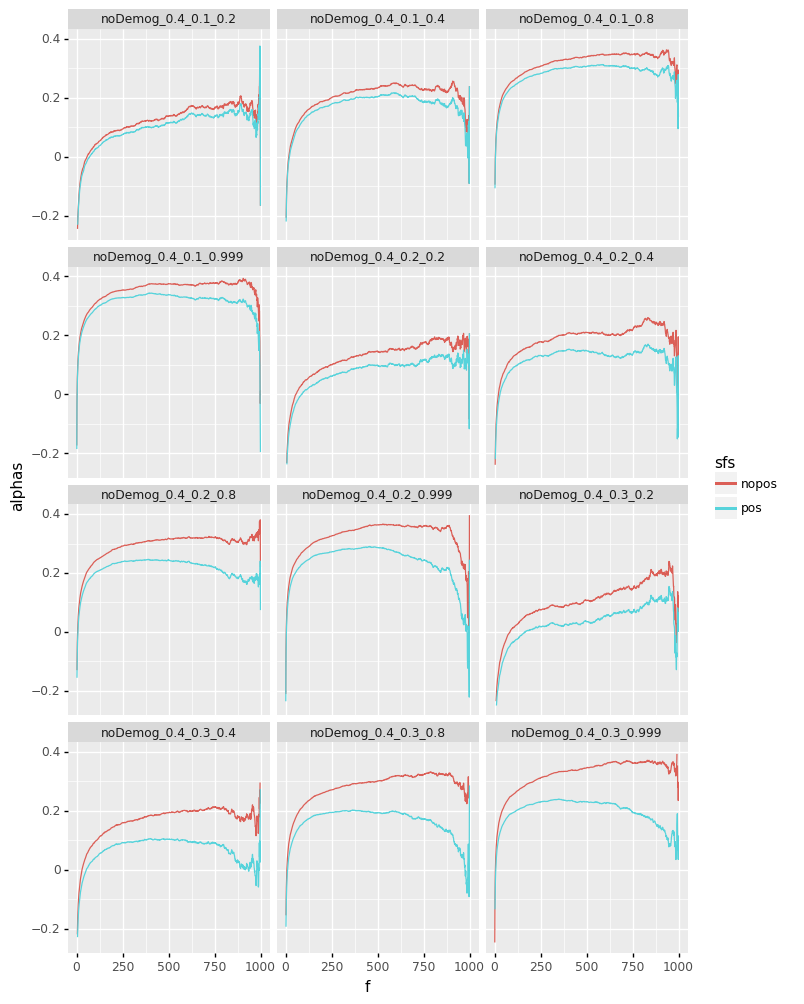

<ggplot: (8768465753049)>

In [23]:
plt.options.figure_size=(8,12)
p = (ggplot(dfAlpha, aes(x='f',y='alphas',color='sfs')) + geom_line() + facet_wrap('~path',ncol=3) + ylim(-0.25,0.4));p

In [24]:
df,dfAlpha = saveSimulatedAlphas(simTable,reduced=True,bins=100);dfAlpha

/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.1_0.2
/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.2_0.2
/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.3_0.2
/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.1_0.4
/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.2_0.4
/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.3_0.4
/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.1_0.8
/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.2_0.8
/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.3_0.8
/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.1_0.999
/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.2_0.999
/home/jmurga/mkt/202004/rawData/simulations/noDemog/noDemog_0.4_0.3_0.999


,f,alphas,sfs,path
0,1,-0.647849,nopos,noDemog_0.4_0.1_0.2
1,2,-0.158575,nopos,noDemog_0.4_0.1_0.2
2,3,-0.084182,nopos,noDemog_0.4_0.1_0.2
3,4,-0.047678,nopos,noDemog_0.4_0.1_0.2
4,5,-0.028115,nopos,noDemog_0.4_0.1_0.2
...,...,...,...,...
95,96,0.079887,pos,noDemog_0.4_0.3_0.999
96,97,0.099639,pos,noDemog_0.4_0.3_0.999
97,98,0.132635,pos,noDemog_0.4_0.3_0.999
98,99,0.078286,pos,noDemog_0.4_0.3_0.999


In [28]:
dfAlpha.to_csv(PATH + '/results/simulations/alphasSimulations/simulatedToPlotReduced.tsv',index=False,sep='\t',header=True)

/home/jmurga/.conda/lib/python3.8/site-packages/plotnine/geoms/geom_path.py:75: PlotnineWarning: geom_path: Removed 2 rows containing missing values.


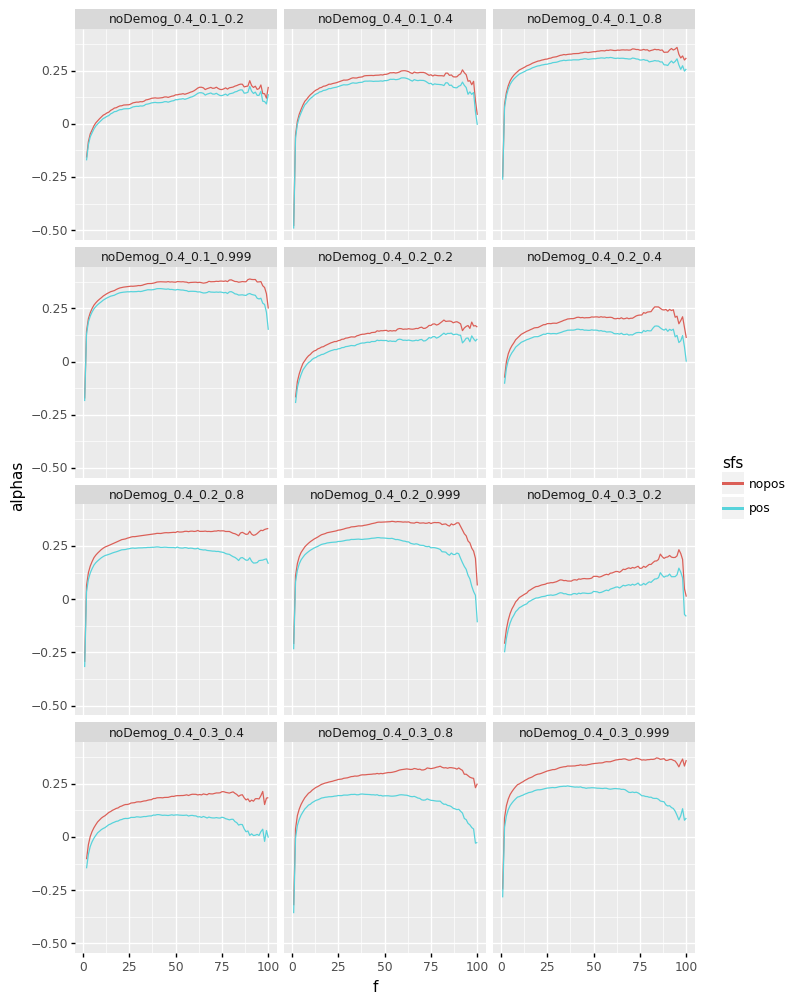

<ggplot: (8768468840683)>

In [27]:
plt.options.figure_size=(8,12)
p = (ggplot(dfAlpha, aes(x='f',y='alphas',color='sfs')) + geom_line() + facet_wrap('~path',ncol=3) + ylim(-0.5,0.4));p

In [44]:
dfAlpha.to_csv(PATH + '/results/simulations/alphasSimulations/simulatedToPlotReduced.tsv',index=False,sep='\t',header=True)

In [64]:
ggsave(p,file="/home/jmurga/sim.svg")

/home/jmurga/.conda/lib/python3.8/site-packages/plotnine/ggplot.py:727: PlotnineWarning: Saving 6.4 x 4.8 in image.
/home/jmurga/.conda/lib/python3.8/site-packages/plotnine/ggplot.py:730: PlotnineWarning: Filename: plotnine-save-8764060314998.pdf


### Julia analysis

In [ ]:
nthreads=7
iteration=round(10**6/17)+1

Each Julia iteration performs 17 estimations accounting for 17 different BGS values regarding a fixed alpha value. To make about 10^6 summary statistics we parallelize (10^6/17/threads) iterations. Each thread will write a different file that I will join using bash to input in ABCreg. I will storaged a file called rJob.sh which should be executed to perform the ABC.

In [ ]:
priorsJulia(table=tmpSim,nSimulations=iteration,pSize=500,nSize=500,model="noDemog",script="/home/jmurga/mkt/202004/scripts/src/sim.jl",bins=100,threads=nthreads,replicas=[1,nthreads],precomipledImg="/home/jmurga/mktest.so",parallelPath="/home/jmurga/.conda/envs/abcmk/bin/parallel")

# Tennesen model

## Solving values to simulate with Analytical.jl

In [ ]:
!which julia

In [ ]:
!julia /home/jmurga/mkt/202004/scripts/src/simTable.jl 7310 100000 tennensen.tsv

### Solving values to simulate with Analytical.jl

In [17]:
simTable = pd.read_csv(PATH + "/rawData/simulations/tennesen.tsv", sep='\t')
simTable['path'] = simTable.apply(lambda row: "/home/jmurga/mkt/202004/rawData/simulations/tennesen/tennesen_" + str(row['alpha']) + "_" + str(row['alphaW']) + "_" + str(np.round(row['B'],4)),axis=1)

To test just one case I select one row from simTable

In [18]:
tmpSim = simTable.tail(1);tmpSim

,bgsThetaF,pposL,pposH,alphaW,alpha,estimation,B,path
11,9.500000e-11,0.011536,0.000079,0.3,0.4,0.40374,0.999,/home/jmurga/mkt/202004/rawData/simulations/te...


### Running SLiM

Generating replicates and folders. It depends on GNU parallel tool and SLiM

In [ ]:
nSamples=661
binnedSfs=(nSamples*2)-1

In [ ]:
for index,row in tmpSim.iterrows():
    print(index,row.path);tmp = pd.DataFrame(row).T
    
    runSlim(recipe="/home/jmurga/mkt/202004/scripts/slimRecipes/bgs.slim",simTable=tmpSim,pSize=7310,codingLength=2000,strongStrength=500,weaklyStrength=10,bins=binnedSfs,replicas=[1,30000],threads=7,slimPath="/home/jmurga/.conda/envs/abcmk/bin/slim",parallelPath="/home/jmurga/.conda/envs/abcmk/bin/parallel")

### Processing simulated data

In [20]:
for index,row in tmpSim.iterrows():
    parsePolDiv(row.path,binnedSfs)

100%|██████████| 1341/1341 [00:01<00:00, 1033.71it/s]


In [ ]:
out = [];al = [];
for index,row in tmpSim.iterrows():
    print(row.path)
    sfs = pd.read_csv(row.path + "/sfs.tsv",header=0,sep="\t")
    div = pd.read_csv(row.path + "/div.tsv",header=0,sep="\t")
    # alphas = pd.read_csv(row.path + "/alphas.tsv",header=0,sep="\t")
    alphas = div.dw/div.di
    try:
        cSfs = cumulativeSfs(sfs.to_numpy())
        asymp1 = amkt(cSfs[:,[0,4,2]],div.to_numpy().flatten(),0,1)
        asymp2 = amkt(cSfs[:,[0,1,2]],div.to_numpy().flatten(),0,1)
    except:
        
        cSfs = cumulativeSfs(reduceSfs(sfs.to_numpy(),100))
        asymp1 = amkt(cSfs[:,[0,4,2]],div.to_numpy().flatten(),0,1)
        try:            
            asymp2 = amkt(cSfs[:,[0,1,2]],div.to_numpy().flatten(),0,1)
        except:
            asymp2 = [None] * 2
            asymp2[0] = dict({'alpha':0})
            asymp2[1]= np.zeros(100)
            
    tmp1 = pd.DataFrame({'trueAlphaW':alphas})
    tmp1['asymp_nopos'] = asymp1[0]['alpha']
    tmp1['asymp'] = asymp2[0]['alpha']
    tmp1['analyticalEstimation']= row.estimation
    tmp1['path'] = row.path.split('/')[-1]
    tmp2 = pd.DataFrame({'path':row.path.split('/')[-1],'alpha':asymp2[1],'alpha_nopos':asymp1[1],'f':np.arange(1,101)}) 
    out.append(tmp1)
    al.append(tmp2)
df = pd.concat(out).reset_index(drop=True)
alphas = pd.concat(al)

In [ ]:
df

### Julia Analysis

In [ ]:
iteration=(10**6/17/4)

Each Julia iteration performs 17 estimations accounting for 17 different BGS values regarding a fixed alpha value. To make about 10^6 summary statistics we parallelize (10^6/17/threads) iterations. Each thread will write a different file that I will join using bash to input in ABCreg. I will storaged a file called rJob.sh which should be executed to perform the ABC.

In [ ]:
priorsJulia(table=tmpSim.head(1),nSimulations=iteration,pSize=1000,nSize=500,model="noDemog",script="/home/jmurga/mkt/202004/scripts/src/sim.jl",threads=4,replicas=[1,4],precomipledImg=None,parallelPath="/home/jmurga/.conda/envs/abcmk/bin/parallel")